Here we will test the rotating frame Hamiltonian considering only the DC terms, i.e those rotate with zero frequency regardless of the drive frequencies, are considered. In that frame the Hamiltonian reads :

$ \widetilde{H}_0 = \Delta_a a^{\dagger}a + \Delta_b b^{\dagger}b + \Delta_c c^{\dagger}c - \Chi_{ab}a^{\dagger}ab^{\dagger}b - \Chi_{bc}c^{\dagger}cb^{\dagger}b - \Chi_{ac}a^{\dagger}ac^{\dagger}c - \Chi_{aa}a^{\dagger}aa^{\dagger}a - \Chi_{bb}b^{\dagger}bb^{\dagger}b - \Chi_{cc}c^{\dagger}cc^{\dagger}c$

$\widetilde{H}_d = j \zeta_a(a^{\dagger}-a) + j \zeta_b(b^{\dagger}-b) + j \zeta_c(c^{\dagger}-c)$
 
 And the total Hamiltonian thus reads $\widetilde{H} = \widetilde{H}_0 + \widetilde{H}_d$.

In [8]:
# Loading the necessary imports
import dynamiqs as dq
import jax.numpy as jnp
from pathlib import Path
import json
import matplotlib.pyplot as plt


In [9]:
# Defining the System Parameters : (Every frequency is in MHz and times are in us)
# Detunings : 
Delta_a = 10.0  
Delta_b = 10.0  
Delta_c = 10.0

# Self-Kerr Nonlinearities :
Xaa = 0.0014
Xbb = 0.0373
Xcc = 164.0

# Cross-Kerr Couplings :
Xab = 0.0072
Xac = 0.671 
Xbc = 3.538

# Decay Rates : 
kappa_a = 0.0042
kappa_b = 0.984
kappa_c = 0.0207
dephase_c = 0.0329

# Drive Amplitudes : 
amp_a = 1.0;  Ea = amp_a * 6.6857
amp_b = 1.0;  Eb = amp_b * 1.0109
amp_c = 0.01;  Ec = amp_c * 141.8580

# Truncation Levels and time points : 
Na = 18
Nb = 18
Nc = 4
td = 500

# Defining the System Operators and initial state
a = dq.destroy(Na);  a = dq.tensor(a, dq.eye(Nb), dq.eye(Nc))
b = dq.destroy(Nb);  b = dq.tensor(dq.eye(Na), b, dq.eye(Nc))
c = dq.destroy(Nc);  c = dq.tensor(dq.eye(Na), dq.eye(Nb), c)

rho0 = dq.tensor(dq.fock_dm(Na, 1), dq.fock_dm(Nb, 0), dq.fock_dm(Nc, 0))

# Constructing the Hamiltonian, Dissipators and Observables in the Rotating Frame
H0 = Delta_a * a.dag() @ a + Delta_b * b.dag() @ b + Delta_c * c.dag() @ c \
+ Xaa * a.dag() @ a.dag() @ a @ a + Xbb * b.dag() @ b.dag() @ b @ b + Xcc * c.dag() @ c.dag() @ c @ c \
+ Xab * a.dag() @ a @ b.dag() @ b + Xac * a.dag() @ a @ c.dag() @ c + Xbc * b.dag() @ b @ c.dag() @ c

Hd = Ea * (a + a.dag()) + Eb * (b + b.dag()) + Ec * (c + c.dag())

Obs = [a.dag() @ a, b.dag() @ b, c.dag() @ c]

Dissipators = [jnp.sqrt(kappa_a) * a, jnp.sqrt(kappa_b) * b, jnp.sqrt(kappa_c) * c, jnp.sqrt(dephase_c) * c.dag() @ c]

# Setting the Scope of the Simulation
tmax = 5.0
times = jnp.linspace(0, tmax, td)



In [10]:
# Running the Simulation
result = dq.mesolve(H0+Hd, Dissipators, rho0, tsave=times, exp_ops=Obs)
print(result)

|██████████| 100.0% ◆ elapsed 14m56s ◆ remaining 0.00ms

==== MESolveResult ====
Method  : Tsit5
Infos   : 4289 steps (4276 accepted, 13 rejected)
States  : QArray complex64 (500, 1296, 1296) | 6.3 Gb
Expects : Array complex64 (3, 500) | 11.7 Kb


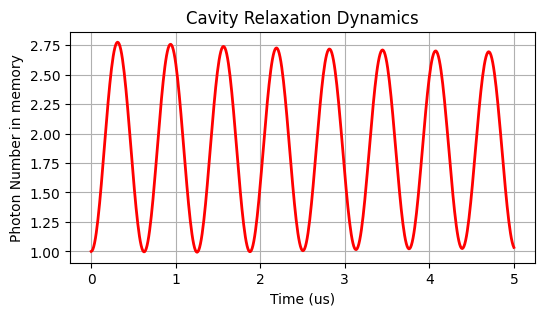

In [11]:
# Analyzing the Result 
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(times, result.expects[0].real, linewidth=2, color = "r")
ax.set_xlabel("Time (us)")
ax.set_ylabel("Photon Number in memory")
ax.set_title("Cavity Relaxation Dynamics")
ax.grid()
